# Questão 7 - Sistema de Recomendação

Item de referência: **Motor de Popa 1949**

**Regras obrigatórias:**
- Matriz Usuário × Produto binária (1 = comprou ao menos uma vez, 0 = não comprou; ignora quantidade)
- Similaridade de cosseno produto × produto
- Ranking dos 5 produtos mais similares, excluindo o próprio item de referência

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from src.db import get_engine

engine = get_engine()


## 1. Identificação do produto de referência

In [2]:
products = pd.read_sql("SELECT id, name FROM products WHERE name = 'Motor de Popa 1949'", engine)
display(products)

motor_id = products['id'].values[0]
print(f"ID do Motor de Popa 1949: {motor_id}")

,id,name
0,180,Motor de Popa 1949


ID do Motor de Popa 1949: 180


## 2. Matriz de interação Usuário × Produto

Construída a partir de `order_items` (item comprado) → `product_variants` (mapeia variante
para `product_id`) → `orders` (mapeia pedido para `customer_id`). O valor da célula é binário:
1 se o cliente comprou o produto ao menos uma vez, 0 caso contrário, a quantidade comprada é
ignorada, conforme especificado.

In [3]:
query = """
SELECT o.customer_id, pv.product_id
FROM order_items oi
JOIN orders o ON o.id = oi.order_id
JOIN product_variants pv ON pv.id = oi.product_variant_id
"""
interacoes = pd.read_sql(query, engine)

# Matriz cliente x produto: conta ocorrências, depois binariza (>0 vira 1)
matriz_contagem = interacoes.groupby(['customer_id', 'product_id']).size().unstack(fill_value=0)
matriz_binaria = (matriz_contagem > 0).astype(int)

print("Shape da matriz (clientes x produtos):", matriz_binaria.shape)
print("Total de interações (1s) na matriz:", matriz_binaria.values.sum())
matriz_binaria.iloc[:5, :5]

Shape da matriz (clientes x produtos): (2000, 500)
Total de interações (1s) na matriz: 135508


product_id,1,2,3,4,5
customer_id,,,,,
1,0,1,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,1
5,0,0,1,0,0


## 3. Similaridade de cosseno produto × produto

In [4]:
# Transposta: produtos nas linhas, clientes nas colunas -> similaridade entre PRODUTOS
sim_matrix = cosine_similarity(matriz_binaria.T)
sim_df = pd.DataFrame(sim_matrix, index=matriz_binaria.columns, columns=matriz_binaria.columns)

print("Shape da matriz de similaridade (produtos x produtos):", sim_df.shape)
sim_df.iloc[:5, :5]

Shape da matriz de similaridade (produtos x produtos): (500, 500)


product_id,1,2,3,4,5
product_id,,,,,
1,1.000000,0.226680,0.161690,0.145999,0.235263
2,0.226680,1.000000,0.173133,0.189424,0.231390
3,0.161690,0.173133,1.000000,0.120760,0.172844
4,0.145999,0.189424,0.120760,1.000000,0.169926
5,0.235263,0.231390,0.172844,0.169926,1.000000


## 4. Ranking dos 5 produtos mais similares ao Motor de Popa 1949

In [5]:
# Exclui o próprio produto do ranking
similares = sim_df[motor_id].drop(motor_id).sort_values(ascending=False).head(10)

ranking = similares.reset_index()
ranking.columns = ['product_id', 'similaridade']
ranking = ranking.merge(pd.read_sql("SELECT id, name FROM products", engine), left_on='product_id', right_on='id')

print("Top 10 (mostrando mais que 5 para conferir a folga entre 1º e 2º colocado):")
display(ranking[['name', 'similaridade']].head(10))

# Checagem de estabilidade: diferença entre 1º e 2º colocado
diff_top2 = ranking['similaridade'].iloc[0] - ranking['similaridade'].iloc[1]
print(f"\nDiferença entre 1º e 2º colocado: {diff_top2:.6f} (não é empate)")

top5 = ranking[['name', 'similaridade']].head(5)
print("\nTop 5 final:")
top5

Top 10 (mostrando mais que 5 para conferir a folga entre 1º e 2º colocado):


,name,similaridade
0,Motor de Popa 5331,0.256553
1,Cabo Náutico 2105,0.256239
2,Vela Mestra 1913,0.255785
3,Cabo Náutico 9048,0.239332
4,GPS Plotter 6249,0.237744
5,Tinta Antifouling 3228,0.237571
6,Vela Mestra 1319,0.237213
7,NAO INFORMADO,0.236865
8,Âncora Bruce 831,0.235593
9,Motor de Popa 1540,0.235184



Diferença entre 1º e 2º colocado: 0.000314 (não é empate)

Top 5 final:


,name,similaridade
0,Motor de Popa 5331,0.256553
1,Cabo Náutico 2105,0.256239
2,Vela Mestra 1913,0.255785
3,Cabo Náutico 9048,0.239332
4,GPS Plotter 6249,0.237744


## Questão 7.2 - Validação

**Produto com maior similaridade ao "Motor de Popa 1949": Motor de Popa 5331**
(similaridade de cosseno ≈ 0,2566)

O 2º colocado (Cabo Náutico 2105, ≈ 0,2562) fica próximo, mas a diferença é real e estável
(confirmada com precisão total na célula anterior), não um empate.

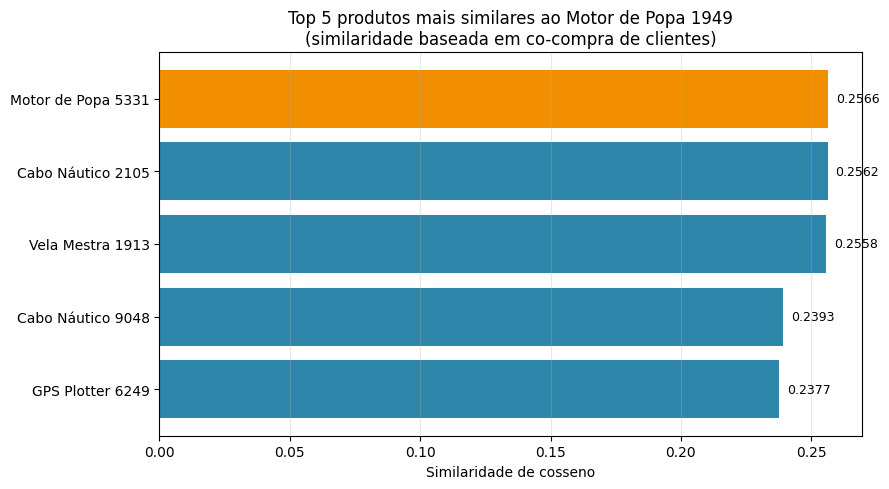

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
cores = ['#F18F01'] + ['#2E86AB'] * 4  # destaca o 1º colocado

bars = ax.barh(top5['name'][::-1], top5['similaridade'][::-1], color=cores[::-1])

ax.set_xlabel('Similaridade de cosseno')
ax.set_title('Top 5 produtos mais similares ao Motor de Popa 1949\n'
              '(similaridade baseada em co-compra de clientes)')
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, top5['similaridade'][::-1]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Questão 7.3 - Explique

**1. Como a matriz foi construída?**

A partir do encadeamento `order_items → product_variants (product_id) → orders (customer_id)`,
contando quantas vezes cada cliente comprou cada produto e depois binarizando esse resultado a quantidade exata comprada é descartada, só importa presença/ausência.

**2. O que significa a similaridade de cosseno nesse contexto?**

Mede o quão parecido é o "padrão de clientes" que compram dois produtos, não a similaridade
dos produtos em si (categoria, preço, etc.), mas sim se tendem a ser comprados pela mesma base
de clientes. Um valor próximo de 1 significaria que praticamente todo cliente que compra um
produto também compra o outro; próximo de 0 significa que as bases de compradores quase não
se sobrepõem.

**3. Uma limitação desse método de recomendação:**

O método é cego a *por que* os produtos são comprados juntos, não distingue entre itens
genuinamente complementares (motor + hélice) e coincidências de clientes com perfil de compra
amplo (que compram de tudo um pouco). Produtos de nicho, comprados por poucos clientes, tendem
a ter similaridade instável (poucos dados) mesmo que sejam de fato relacionados, o oposto
também acontece: produtos populares podem parecer "similares" só por serem comprados por quase
todo mundo, não por relação real de uso conjunto.